With topspin (signs for $C_L$ have to be reversed and $C_L=0$ for flat since no lifting force), we have the following two equations from Brody et al as well as $|C_L|=\frac{1}{2+|v|/|v_{spin}|}$.

\begin{align}
    \frac{dv_x}{dt} &= -kv(C_dv_x-C_Lv_y) \\
    \frac{dv_y}{dt} &= kv(-C_Lv_x-C_dv_y)-g
\end{align}

With $k=\frac{\rho \pi R^2}{2m}$ where $\rho$ is air density, $R$ is the tennis ball's radius, and $m$ is its mass.

Originally, we inferred from the $g$ component for $v_y$ being negative that these are for when the ball is flying upwards, and $\theta$ is the angle at which the ball is flying upward from the horizontal plane, thus setting upwards to be the positive direction in this set-up. However upon testing (see corresponding testing file), we found for implementing these formulas, signs have to be toggled for the drag coefficient according to whether the ball is flying upwards or downwards. We make these changes directly in formula $(3)$ below.

The parameters involved can be set below:

In [1]:
import math
import numpy as np
from matplotlib import pyplot as plt

# constants, all with respect to kilogram, meter, and seconds when applicable
c_d = 0.55 # drag coefficient assumed to be constant but actually changes with spin, source: P385 intial value Brody et al.
rho = 1.29 # air density, source: NASA (earthdata.nasa.gov/topics/atmosphere/atmospheric-pressure/air-mass-density)
r = 0.033 # ball radius, source: 6.6 cm diameter within acceptable bounds of 2023 ITF
m = 0.057 # ball mass, source: P387 example, within acceptable bounds of 2023 ITF
k = rho*math.pi*r**2/(2*m)
g = 9.8

# variable(s)
# average spin velocity depends on whether shot was forehand or backhand
# range from atp site rpm stat (reddit.com/r/tennis/comments/11y5avk/indian_wells_2023_topspin_rates_and_groundstroke)
v_spin = 0 # unit rotations per minute, 2500 forehand, 1500 backhand, positive(negative) for topspin(backspin)
v_spin = v_spin/60*2*math.pi*r
# initial conditions, set for each shot, also change vectorfield chosen and timepoints below accordingly
v0 = 30 # m/s
theta0 = 0.26 # radians

With $v_x = v\cos\theta$ and $v_y = v\sin\theta$, we take derivatives with respect to $t$:

\begin{align}
    v'\cos \theta - v(\sin \theta) \theta ' &= -kv(C_dv\cos\theta-C_Lv\sin\theta) \dots (1) \\
    v'\sin \theta + v(\cos \theta) \theta ' &= kv(-C_Lv\cos\theta-C_dv\sin\theta) - g \dots (2)
\end{align}

$(1)\cos\theta+(2)\sin\theta \\ \Rightarrow v' = -kC_dv^2-g\sin\theta \dots (3)$

$(2)\cos\theta-(1)\sin\theta \\ \Rightarrow \theta' = -kC_Lv-g\cos\theta = -\frac{kv}{2+|v|/|v_{spin}|}-g\cos\theta \dots (4)$

With backspin instead of topspin, only the signs for $C_L$ are reversed, resulting in no change for $(3)$ and a slight change of signs for $(4)$ to be $\theta' = kC_Lv-g\cos\theta = \frac{kv}{2+|v|/|v_{spin}|}-g\cos\theta$.

When the ball is flat, we have $C_L=0$, still yielding no change for $(3)$, while $(4)$ becomes simply $\theta' = -g\cos\theta$.

In all scenarios, who have found it necessary to reverse the sign for the drag component in $(3)$ when the ball starts going downwards. Otherwise that component only helps to accelerate the ball. For this reason we have two systems for each type of spin.

In [2]:
from scipy.integrate import odeint # scipy-cookbook.readthedocs.io/items/CoupledSpringMassSystem.html

In [3]:
def topspin_upwards(w ,t, p):
    """
    Equations for topspin trajectory above in vectorfield form for ODEINT
    when the ball is travelling upwards
    
    Arguments:
        w: vector of the state variables, required order: v, theta
        t: time
        p: vector of parameters, required order: k, c_d, v_spin, g
    """
    
    v, theta = w
    k, c_d, v_spin, g = p
    f = [-k*c_d*v**2-g*math.sin(theta), -k*v/(2+v/abs(v_spin))-g*math.cos(theta)]
    return f
    
def topspin_downwards(w ,t, p):
    """
    Equations for topspin trajectory above in vectorfield form for ODEINT
    when the ball is travelling downwards
    
    Arguments:
        w: vector of the state variables, required order: v, theta
        t: time
        p: vector of parameters, required order: k, c_d, v_spin, g
    """
    
    v, theta = w
    k, c_d, v_spin, g = p
    f = [k*c_d*v**2-g*math.sin(theta), -k*v/(2+v/abs(v_spin))-g*math.cos(theta)]
    return f
    
def backspin_upwards(w ,t, p):
    """
    Equations for backspin trajectory above in vectorfield form for ODEINT
    when the ball is travelling upwards
    
    Arguments:
        w: vector of the state variables, required order: v, theta
        t: time
        p: vector of parameters, required order: k, c_d, v_spin, g
    """
    
    v, theta = w
    k, c_d, v_spin, g = p
    f = [-k*c_d*v**2-g*math.sin(theta), k*v/(2+v/abs(v_spin))-g*math.cos(theta)]
    return f
    
def backspin_downwards(w ,t, p):
    """
    Equations for backspin trajectory above in vectorfield form for ODEINT
    when the ball is travelling downwards
    
    Arguments:
        w: vector of the state variables, required order: v, theta
        t: time
        p: vector of parameters, required order: k, c_d, v_spin, g
    """
    
    v, theta = w
    k, c_d, v_spin, g = p
    f = [k*c_d*v**2-g*math.sin(theta), k*v/(2+v/abs(v_spin))-g*math.cos(theta)]
    return f

def flat_upwards(w ,t, p):
    """
    Equations for flat trajectory above in vectorfield form for ODEINT
    when the ball is travelling upwards
    
    Arguments:
        w: vector of the state variables, required order: v, theta
        t: time
        p: vector of parameters, required order: k, c_d, v_spin, g
    """
    
    v, theta = w
    k, c_d, v_spin, g = p
    f = [-k*c_d*v**2-g*math.sin(theta), -g*math.cos(theta)]
    return f
    
def flat_downwards(w ,t, p):
    """
    Equations for backspin trajectory above in vectorfield form for ODEINT
    when the ball is travelling downwards
    
    Arguments:
        w: vector of the state variables, required order: v, theta
        t: time
        p: vector of parameters, required order: k, c_d, v_spin, g
    """
    
    v, theta = w
    k, c_d, v_spin, g = p
    f = [-k*c_d*v**2-g*math.sin(theta), -g*math.cos(theta)]
    return f

#### pre-bounce upwards trajectory

In [4]:
# Set-up from the cookbook example
# ODE solver parameters
# adjust stoptime and numpoints for each shot
abserr = 1.0e-8
relerr = 1.0e-6
stoptime = 2
numpoints = 500
# Create the time samples for the output of the ODE solver.
# I use a large number of points, only because I want to make
# a plot of the solution that looks nice.
t = [stoptime * float(i) / (numpoints - 1) for i in range(numpoints)]
# Pack up the parameters and initial conditions:
p = [k, c_d, v_spin, g]
w0 = [v0, theta0]
if v_spin > 0:
    vectorfield = topspin_upwards
elif v_spin < 0:
    vectorfield = backspin_upwards
else:
    vectorfield = flat_upwards

In [5]:
# Call the ODE solver.
pre_up = odeint(vectorfield, w0, t, args=(p,), atol=abserr, rtol=relerr)
cutoff_pre = np.argmax(np.array(pre_up[:,1]) < 0)

In [7]:
unit_t = stoptime/(numpoints-1)
x_pre_up = [0]*(cutoff_pre+1)
y_pre_up = [0]*(cutoff_pre+1)
for i in range(cutoff_pre):
    x_pre_up[i+1] = x_pre_up[i] + unit_t*pre_up[i,0]*math.cos(pre_up[i,1])
    y_pre_up[i+1] = y_pre_up[i] + unit_t*pre_up[i,0]*math.sin(pre_up[i,1])

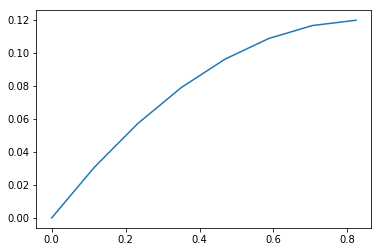

In [8]:
plt.plot(x_pre_up, y_pre_up)

#### pre-bounce downwards trajectory

In [9]:
w1 = [pre_up[cutoff_pre,0], pre_up[cutoff_pre,1]]
if v_spin > 0:
    vectorfield = topspin_downwards
elif v_spin < 0:
    vectorfield = backspin_downwards
else:
    vectorfield = flat_downwards
pre_down = odeint(vectorfield, w1, t, args=(p,), atol=abserr, rtol=relerr)

In [10]:
unit_t = stoptime/(numpoints-1)
x_pre_down = [0]*(numpoints+1)
y_pre_down = [0]*(numpoints+1)
for i in range(numpoints):
    x_pre_down[i+1] = x_pre_down[i] + unit_t*pre_down[i,0]*math.cos(pre_down[i,1])
    y_pre_down[i+1] = y_pre_down[i] + unit_t*pre_down[i,0]*math.sin(pre_down[i,1])
cutoff_bounce = np.argmax(np.array(y_pre_down) < -y_pre_up[cutoff_pre]-1)

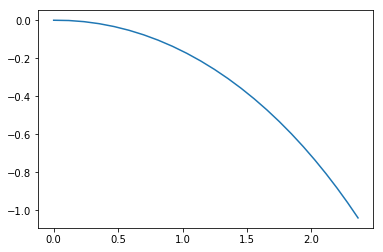

In [11]:
plt.plot(x_pre_down[:cutoff_bounce],y_pre_down[:cutoff_bounce])

Next step is to visualize and extract the proportions of distance at height 1 meter to obtain the hitting windows. For each time point's $v$ and $\theta$, we move the ball forward $vt\cos\theta$ and upwards $vt\sin\theta$ (which can be negative) where $t$ is stoptime/numpoints above.

In [ ]:
unit_t = stoptime/(numpoints-1)
x = [0]*(numpoints+1)
y = [0]*(numpoints+1)
for i in range(numpoints):
    x[i+1] = x[i] + unit_t*wsol[i,0]*math.cos(wsol[i,1])
    y[i+1] = y[i] + unit_t*wsol[i,0]*math.sin(wsol[i,1])

In [ ]:
wsol

In [ ]:
plt.plot(x,y)

We also want the trajectory of the ball after the bounce. In our model, a bounce uniformly results in an accumulation of topspin speed of 40 rps (Brody et al. used this for demonstrational purposes in P217). With our additional simplification of the exit angle being the same as the entry angle, the ball also has its speed $v$ reduced by a factor of the coefficient of restitution.

In [ ]:
# customizable constants
cor = 0.8
spin_acc_rps = 40
stoptime2 = 10 # long so don't have to adjust manually
# Find the -1 meter cutoff in wsol where the ball hits the ground
cutoff = np.argmax(np.array(y) <= -1)
v_1, theta_bounce = wsol[cutoff,:] # speed and angle into bounce
theta_bounce = -theta_bounce
# Get new spin speed and initial speed, angle
v_2 = v_1*cor
v_spin2 = v_spin + spin_acc_rps*2*math.pi*r
if v_spin2 > 0:
    vectorfield = topspin_equations
elif v_spin2 < 0:
    vectorfield = backspin_equations
else:
    vectorfield = flat_equations
p2 = [k, c_d, v_spin2, g]
w0_2 = [v_2, theta_bounce]
# get t2 time array for ODE solver
numpoints2 = math.ceil(stoptime2/unit_t)
t2 = [stoptime2 * float(i) / (numpoints2 - 1) for i in range(numpoints2)]

In [ ]:
wsol2 = odeint(vectorfield, w0_2, t2, args=(p2,), atol=abserr, rtol=relerr)
# wsol2

In [ ]:
x2 = [0]*(numpoints2+1)
x2 = [i+x[cutoff-1] for i in x2] # add distance covered pre-bounce
y2 = [0]*(numpoints2+1)
y2 = [i-1 for i in y2] # shift ground level to be -1 to align with pre-bounce
for i in range(numpoints2):
    x2[i+1] = x2[i] + unit_t*wsol2[i,0]*math.cos(wsol2[i,1])
    y2[i+1] = y2[i] + unit_t*wsol2[i,0]*math.sin(wsol2[i,1])
cutoff2 = np.argmax(np.array(y2[1:]) <= -1)
x_traj = x[:cutoff]+x2[:cutoff2]
y_traj = y[:cutoff]+y2[:cutoff2]

In [ ]:
plt.plot(x_traj,y_traj)
ax = plt.gca()
ax.set_aspect('equal', adjustable='box')
plt.axhline(y=0.75-1, color='r', linestyle='--')

Here we often have the ball not bouncing back to 1 meter high. Our fix is for hitting windows to be taken on a shot-by-shot basis during shot initialization, with the additional simplification that for a given shot, the ball's height when hit (mostly 1 meter) will be fixed and we ignore the discrepancy between this fixed height and the height of the window from the previous shot.

In [ ]:
# extracting fractions of pre-bounce distance for windows
x_traj[cutoff-1] # 2.548023846722918

In [ ]:
wsol[0,]

In [ ]:
cutoff*unit_t

In [ ]:
abs(2)